# 04 -- Demand Estimation (Phase 1)

Implements outline section **3.4.1 Phase 1: Demand Estimation**:

$$D_i(\alpha) = (H_i C_i) \times P_d \times P_{pub} \times U_i \times (1 + \alpha \cdot IMD_i)$$

Answers **O1**: estimate baseline EV charging demand for each LSOA and apply alternative
income-deprivation weights to construct equity-prioritised demand scenarios.

**Rebuilt against the current `02_data_cleaning_revised.ipynb` outputs** -- the supply file's
schema changed since the old version of this notebook (`ej/seff/ubar_i` -> `e_i/S_eff_i/U_i`),
and critically: **the `U_i` column in `lsoa_supply_clean.csv` is $\bar u_i$ (mean observed
utilisation, 0-1, not yet +1) -- it is NOT the same quantity as the demand formula's $U_i$
multiplier (1-2, already includes the +1).** This notebook renames the raw column to `ubar_i`
immediately on load and builds the formula's `Ui_multiplier` explicitly, so the two never get
conflated.

No demand normalisation across $\alpha$ scenarios (per the current methodology decision):
raising $\alpha$ is allowed to genuinely increase total recognised demand, not just
redistribute a fixed total -- $\Sigma_i D_i(\alpha)$ is expected to grow monotonically with
$\alpha$, and that growth is reported as a deliberate feature, not normalised away.

## 0. Setup and load cleaned data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"
OUTPUT_DIR = os.path.join(BASE, "05_processed")
figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

census_london = pd.read_csv(os.path.join(OUTPUT_DIR, "census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(OUTPUT_DIR, "imd_london_clean.csv"))
lsoa_supply   = pd.read_csv(os.path.join(OUTPUT_DIR, "lsoa_supply_clean.csv"))

print("census_london:", census_london.shape, "| columns:", list(census_london.columns))
print("imd_london:   ", imd_london.shape, "| columns:", list(imd_london.columns))
print("lsoa_supply:  ", lsoa_supply.shape, "| columns:", list(lsoa_supply.columns))

assert len(census_london) == 4_994, f"Expected 4,994 London LSOAs, got {len(census_london)}"
assert set(census_london["lsoa_code"]) == set(imd_london["lsoa_code"]) == set(lsoa_supply["lsoa_code"]), \
    "LSOA code sets differ between census, IoD and supply tables."
print("\nAll three inputs cover the same 4,994 Greater London LSOAs.")

census_london: (4994, 9) | columns: ['lsoa_code', 'lsoa_name', 'Hi', 'Ci', 'vehicle_stock_proxy', 'cars_0', 'cars_1', 'cars_2', 'cars_3plus']
imd_london:    (4994, 10) | columns: ['lsoa_code', 'lsoa_name', 'lad_code', 'lad_name', 'imd_score', 'imd_rank', 'imd_decile', 'income_score', 'income_rank', 'income_decile']
lsoa_supply:   (4994, 9) | columns: ['lsoa_code', 'lsoa_name', 'e_i', 'S_eff_i', 'U_i', 'n_evse', 'n_active_evse', 'n_active_locations', 'has_evse_i']

All three inputs cover the same 4,994 Greater London LSOAs.


## Step 1: Household vehicle-stock base

$H_i$ = number of households; $C_i$ = average car/van ownership per household
(household-weighted mean across the four TS045 bands, "3 or more" conservatively treated as 3
-- both already computed in `02_data_cleaning_revised.ipynb`).

$H_i C_i$ estimates the number of household vehicles potentially requiring charging.
**Rationale:** vehicle-owning households provide a more direct basis for charging demand than
total population.

In [2]:
demand = census_london[["lsoa_code", "lsoa_name", "Hi", "Ci", "vehicle_stock_proxy"]].copy()

# Hi x Ci, computed explicitly to trace the formula step -- must equal the already-computed
# vehicle_stock_proxy column from 02 (that column IS Hi*Ci, just computed a different way there).
demand["HiCi"] = demand["Hi"] * demand["Ci"]

check_diff = (demand["HiCi"] - demand["vehicle_stock_proxy"]).abs().max()
assert check_diff < 1e-6, f"Hi*Ci does not match vehicle_stock_proxy; max diff={check_diff}"
print(f"Hi*Ci matches vehicle_stock_proxy from 02 (max diff={check_diff:.2e}).")

print("\nHi*Ci (household vehicle stock) summary:")
print(demand["HiCi"].describe())

Hi*Ci matches vehicle_stock_proxy from 02 (max diff=2.27e-13).

Hi*Ci (household vehicle stock) summary:
count    4994.000000
mean      545.504005
std       214.164125
min        69.000000
25%       373.000000
50%       535.000000
75%       707.000000
max      1435.000000
Name: HiCi, dtype: float64


## Step 2: Public-charging demand parameters

$P_d$ = probability a vehicle needs charging on a given day; $P_{pub}$ = proportion of charging
events occurring at public facilities. Both national constants from the DfT EV Tracker Year 1
report (§8.5) -- applied uniformly, not LSOA-varying.

**Rationale:** not every vehicle charges daily, and only part of total charging demand is
served by public infrastructure.

In [3]:
Pd = 4.3 / 14
Ppub = 1.8 / 4.4

print(f"Pd   = 4.3 / 14  = {Pd:.6f}")
print(f"Ppub = 1.8 / 4.4 = {Ppub:.6f}")

Pd   = 4.3 / 14  = 0.307143
Ppub = 1.8 / 4.4 = 0.409091


## Step 3: Utilisation-pressure adjustment ($U_i$)

$$U_i = \begin{cases} 1 + \bar u_i, & e_i > 0 \\ 1, & e_i = 0 \end{cases}$$

$\bar u_i$ = mean observed on-street location utilisation from `lsoa_supply_clean.csv`
(constructed in Phase 2 / `02_data_cleaning_revised.ipynb` from September 2025 session data).
LSOAs with no existing on-street location receive the neutral adjustment ($U_i=1$) rather than
being treated as having zero utilisation pressure.

**Renaming on load, deliberately:** the source CSV column is literally called `U_i` but holds
$\bar u_i$ (0-1, pre-transform) -- renamed to `ubar_i` here immediately so it can never be
confused with the formula's $U_i$ multiplier (1-2, post-transform), which is built explicitly
below as `Ui_multiplier`.

**Rationale:** vehicle ownership alone may not capture local pressure already visible in the
use of existing infrastructure.

In [4]:
supply = lsoa_supply[["lsoa_code", "e_i", "U_i", "has_evse_i"]].rename(
    columns={"U_i": "ubar_i"}
)

# Recomputed from e_i directly rather than trusting the CSV's boolean round-trip, which can be
# ambiguous depending on how True/False strings get re-parsed.
supply["has_evse_i"] = supply["e_i"] > 0

demand = demand.merge(supply, on="lsoa_code", how="left", validate="one_to_one")
assert demand["ubar_i"].isna().sum() == (~demand["has_evse_i"]).sum(), \
    "ubar_i should be NaN exactly where has_evse_i is False."

demand["Ui_multiplier"] = np.where(demand["has_evse_i"], 1 + demand["ubar_i"], 1.0)

assert demand["Ui_multiplier"].isna().sum() == 0, "Ui_multiplier contains unexpected NaNs."
assert demand["Ui_multiplier"].ge(1.0).all(), "Ui_multiplier should never fall below 1."
assert demand["Ui_multiplier"].le(2.0).all(), "Ui_multiplier should never exceed 2 (ubar_i in [0,1])."

print("LSOAs with existing on-street provision (has_evse_i=True):", int(demand["has_evse_i"].sum()))
print("LSOAs with Ui_multiplier == 1 exactly (neutral, no provision):",
      int((demand["Ui_multiplier"] == 1.0).sum()))
print("\nUi_multiplier summary:")
print(demand["Ui_multiplier"].describe())

LSOAs with existing on-street provision (has_evse_i=True): 3157
LSOAs with Ui_multiplier == 1 exactly (neutral, no provision): 2241

Ui_multiplier summary:
count    4994.000000
mean        1.016706
std         0.029719
min         1.000000
25%         1.000000
50%         1.004001
75%         1.021973
max         1.386982
Name: Ui_multiplier, dtype: float64


## Step 4: Income-deprivation weighting

$$1 + \alpha \cdot IMD_i$$

$IMD_i$ = IoD2025 Income Domain Score (`income_score` in `imd_london_clean.csv`; NOT the
composite Index of Multiple Deprivation -- the notation is retained for formula consistency
only). $\alpha$ tested across $\{0, 0.1, 0.3, 0.5\}$ (Scenarios A/B/C/D), with $\alpha=0$ as
the unweighted baseline.

**No normalisation:** because $IMD_i > 0$ for every LSOA, $\Sigma_i D_i(\alpha)$ increases
monotonically with $\alpha$ by construction -- this is retained as a deliberate, interpretable
feature of the equity weighting (stronger deprivation weighting recognises more previously
unrecognised need), not normalised back to a fixed total.

**Rationale:** relying only on currently visible vehicle demand may reproduce existing
inequalities. **Interpretation:** increasing $\alpha$ does not mean deprived areas contain more
vehicles -- it means their potential charging need receives greater planning priority.

In [5]:
demand = demand.merge(
    imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left", validate="one_to_one"
)
demand = demand.rename(columns={"income_score": "IMD_i"})
assert demand["IMD_i"].isna().sum() == 0
assert demand["IMD_i"].between(0, 1).all(), "IMD_i (Income Domain Score) must lie in [0,1]."

SCENARIOS = {"A": 0.0, "B": 0.1, "C": 0.3, "D": 0.5}

HiCi = demand["HiCi"].to_numpy()
Ui = demand["Ui_multiplier"].to_numpy()
IMDi = demand["IMD_i"].to_numpy()

for label, alpha in SCENARIOS.items():
    demand[f"D_{label}"] = HiCi * Pd * Ppub * Ui * (1 + alpha * IMDi)

print("alpha=0 (Scenario A) equals the unweighted baseline (Hi*Ci * Pd * Ppub * Ui):",
      bool(np.allclose(demand["D_A"], HiCi * Pd * Ppub * Ui)))

alpha=0 (Scenario A) equals the unweighted baseline (Hi*Ci * Pd * Ppub * Ui): True


## Output: sanity checks

Three checks the demand construction should satisfy before being used downstream:
1. Total recognised demand grows monotonically with $\alpha$ (not normalised away).
2. $D_i(\alpha)$ becomes more correlated with $IMD_i$ as $\alpha$ increases (the equity
   mechanism is actually doing something).
3. The extra demand added by higher $\alpha$ is concentrated in high-$IMD_i$ LSOAs, not
   scattered evenly (by construction, but worth confirming numerically).

In [6]:
scenario_cols = [f"D_{label}" for label in SCENARIOS]

print("=== Total recognised demand by scenario (expected to grow with alpha) ===")
totals = {}
for label, alpha in SCENARIOS.items():
    total = demand[f"D_{label}"].sum()
    totals[label] = total
    pct_vs_baseline = (total / totals["A"] - 1) * 100 if "A" in totals else 0.0
    print(f"Sigma D_{label} (alpha={alpha}): {total:,.2f}  ({pct_vs_baseline:+.2f}% vs Scenario A)")

is_monotonic = all(totals[a] <= totals[b] for a, b in zip("ABCD", "BCD"))
print(f"\nMonotonically increasing with alpha: {is_monotonic}")
assert is_monotonic, "Total recognised demand should not decrease as alpha increases."

print("\n=== Pearson r: D_scenario vs IMD_i (should increase with alpha) ===")
correlations = {}
for label, alpha in SCENARIOS.items():
    r, p = pearsonr(demand[f"D_{label}"], demand["IMD_i"])
    correlations[label] = r
    print(f"Scenario {label} (alpha={alpha}): r = {r:.4f}, p = {p:.4g}")

is_corr_increasing = all(correlations[a] <= correlations[b] for a, b in zip("ABCD", "BCD"))
print(f"\nCorrelation with IMD_i increases with alpha: {is_corr_increasing}")
assert is_corr_increasing, "Higher alpha should correlate more strongly with IMD_i, not less."

demand["pct_increase_D_vs_A"] = (demand["D_D"] / demand["D_A"] - 1) * 100
extra_demand_corr, _ = pearsonr(demand["IMD_i"], demand["pct_increase_D_vs_A"])
print(f"\nCorrelation between IMD_i and %-increase (Scenario D vs A): {extra_demand_corr:.4f}")
print("(Should be strongly positive: the demand added by equity weighting should concentrate")
print(" in higher-IMD LSOAs, not be spread evenly across London.)")

=== Total recognised demand by scenario (expected to grow with alpha) ===
Sigma D_A (alpha=0.0): 347,150.71  (+0.00% vs Scenario A)
Sigma D_B (alpha=0.1): 355,754.51  (+2.48% vs Scenario A)
Sigma D_C (alpha=0.3): 372,962.12  (+7.44% vs Scenario A)
Sigma D_D (alpha=0.5): 390,169.72  (+12.39% vs Scenario A)

Monotonically increasing with alpha: True

=== Pearson r: D_scenario vs IMD_i (should increase with alpha) ===
Scenario A (alpha=0.0): r = -0.4033, p = 1.009e-194
Scenario B (alpha=0.1): r = -0.3750, p = 1.498e-166
Scenario C (alpha=0.3): r = -0.3190, p = 1.652e-118
Scenario D (alpha=0.5): r = -0.2643, p = 1.334e-80

Correlation with IMD_i increases with alpha: True

Correlation between IMD_i and %-increase (Scenario D vs A): 1.0000
(Should be strongly positive: the demand added by equity weighting should concentrate
 in higher-IMD LSOAs, not be spread evenly across London.)


## Save output

In [7]:
output_cols = [
    "lsoa_code", "lsoa_name", "Hi", "Ci", "HiCi", "e_i", "ubar_i", "has_evse_i",
    "Ui_multiplier", "IMD_i", "D_A", "D_B", "D_C", "D_D",
]
demand_output = demand[output_cols].copy()

output_path = os.path.join(OUTPUT_DIR, "demand_london.csv")
demand_output.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Rows: {len(demand_output)}")
demand_output.head()

Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_london.csv
Rows: 4994


,lsoa_code,lsoa_name,Hi,Ci,HiCi,e_i,ubar_i,has_evse_i,Ui_multiplier,IMD_i,D_A,D_B,D_C,D_D
0,E01000001,City of London 001A,837.0,0.395460,331.0,1,0.243911,True,1.243911,0.013,51.734189,51.801443,51.935952,52.070461
1,E01000002,City of London 001B,824.0,0.359223,296.0,1,0.015972,True,1.015972,0.018,37.786227,37.854242,37.990272,38.126303
2,E01000003,City of London 001C,1017.0,0.216323,220.0,0,NaN,False,1.000000,0.107,27.642857,27.938636,28.530193,29.121750
3,E01000005,City of London 001E,479.0,0.248434,119.0,0,NaN,False,1.000000,0.211,14.952273,15.267766,15.898752,16.529737
4,E01000006,Barking and Dagenham 016A,554.0,0.931408,516.0,0,NaN,False,1.000000,0.343,64.835065,67.058908,71.506593,75.954279


## Demand maps -- all four scenarios, shared colour scale

**Colour scheme: OrRd**, consistent with the EDA panels (03) and the xj allocation maps (05b)
-- all non-negative LSOA-level magnitude maps in this dissertation use the same single-hue
sequential ramp, so "darker = higher" means the same thing everywhere without the reader
re-learning it panel to panel.

LSOA boundaries matched: 4994 / 4994 expected


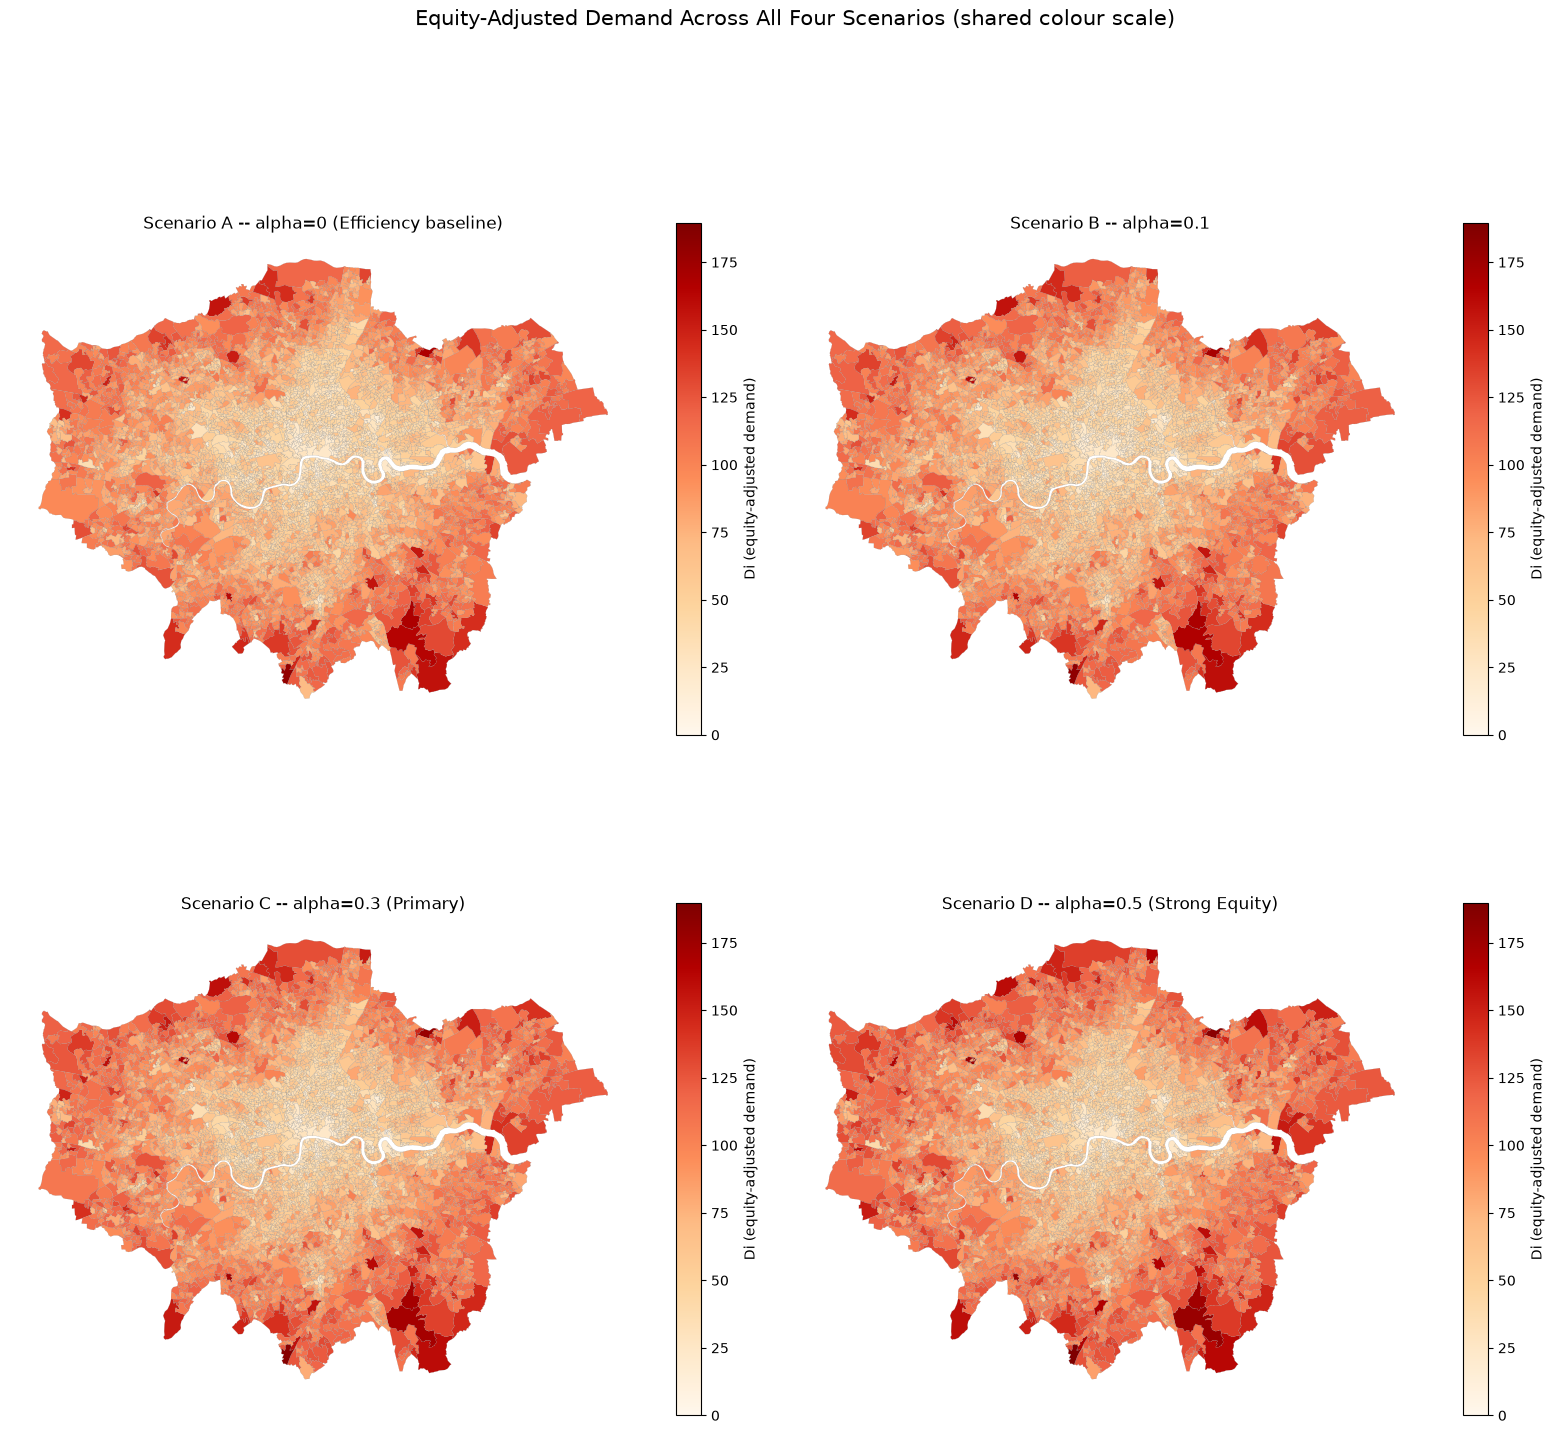

In [8]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

london_codes = set(demand_output["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

demand_map = lsoa_london.merge(demand_output[["lsoa_code"] + scenario_cols], on="lsoa_code", how="left")
shared_vmax = demand_output[scenario_cols].max().max()
labels = {"A": "alpha=0 (Efficiency baseline)", "B": "alpha=0.1",
          "C": "alpha=0.3 (Primary)", "D": "alpha=0.5 (Strong Equity)"}

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for ax, s in zip(axes.flat, ["A", "B", "C", "D"]):
    demand_map.plot(column=f"D_{s}", cmap="OrRd", vmin=0, vmax=shared_vmax, linewidth=0.1,
                     edgecolor="grey", legend=True, ax=ax,
                     legend_kwds={"label": "Di (equity-adjusted demand)", "shrink": 0.6})
    ax.set_title(f"Scenario {s} -- {labels[s]}", fontsize=12)
    ax.axis("off")
plt.suptitle("Equity-Adjusted Demand Across All Four Scenarios (shared colour scale)", fontsize=15, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_scenarios_ABCD.png"), dpi=300, bbox_inches="tight")
plt.show()

## Where equity weighting adds demand (Scenario B/C/D minus Scenario A)

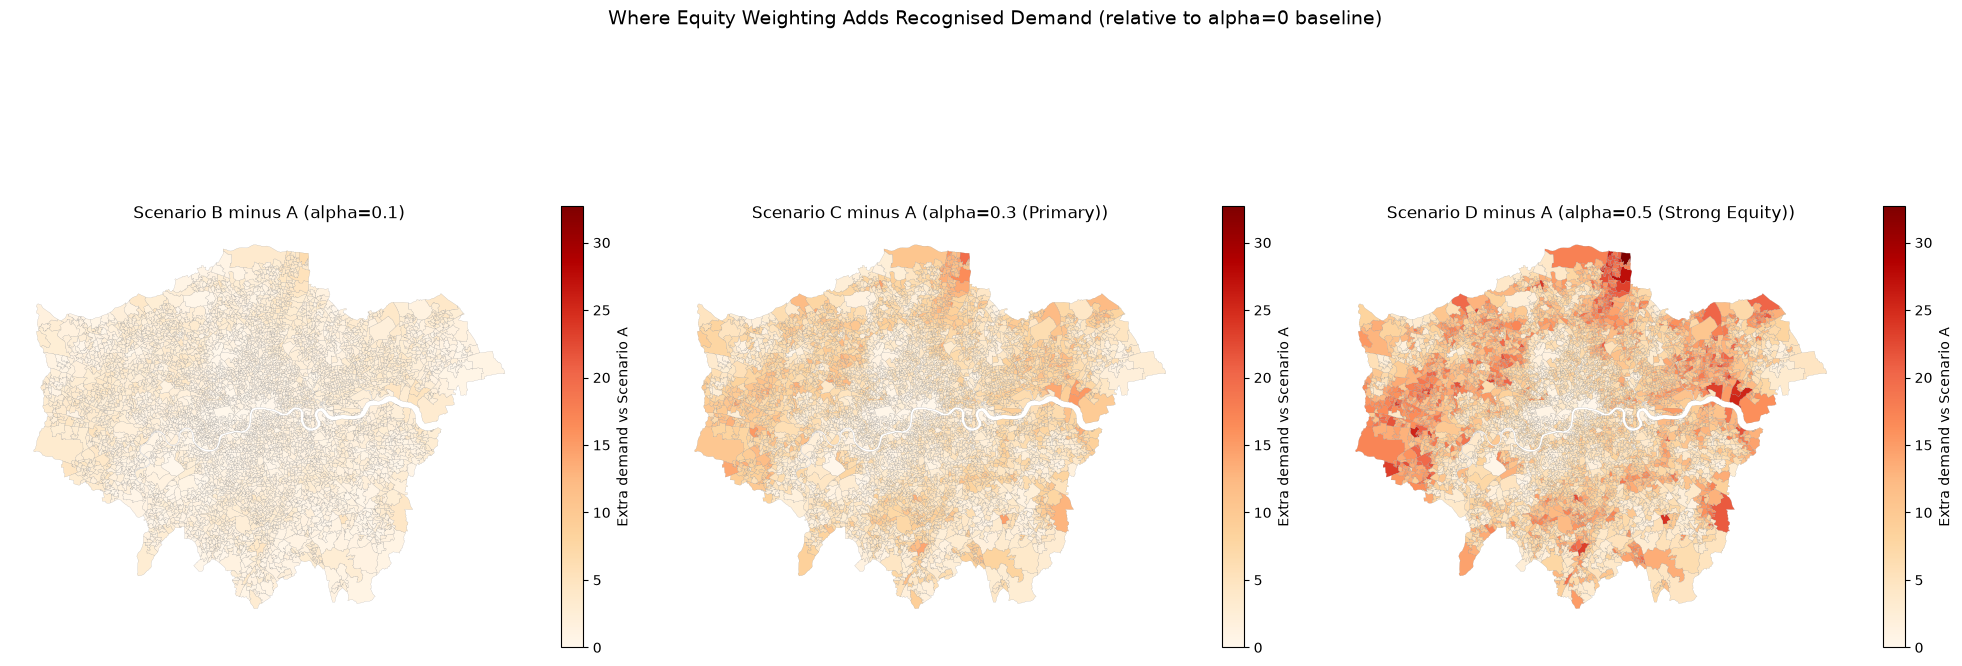

Delta summary (extra demand vs Scenario A):
           delta_B      delta_C      delta_D
count  4994.000000  4994.000000  4994.000000
mean      1.722828     5.168484     8.614140
std       0.944659     2.833977     4.723295
min       0.029126     0.087377     0.145628
25%       0.980624     2.941873     4.903122
50%       1.603050     4.809151     8.015252
75%       2.359889     7.079666    11.799443
max       6.541406    19.624217    32.707029


In [9]:
for s in ["B", "C", "D"]:
    demand_map[f"delta_{s}"] = demand_map[f"D_{s}"] - demand_map["D_A"]

shared_vmax_delta = demand_map[[f"delta_{s}" for s in ["B", "C", "D"]]].max().max()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
delta_labels = {"B": "alpha=0.1", "C": "alpha=0.3 (Primary)", "D": "alpha=0.5 (Strong Equity)"}
for ax, s in zip(axes, ["B", "C", "D"]):
    demand_map.plot(column=f"delta_{s}", cmap="OrRd", vmin=0, vmax=shared_vmax_delta, linewidth=0.1,
                     edgecolor="grey", legend=True, ax=ax,
                     legend_kwds={"label": "Extra demand vs Scenario A", "shrink": 0.6})
    ax.set_title(f"Scenario {s} minus A ({delta_labels[s]})", fontsize=12)
    ax.axis("off")
plt.suptitle("Where Equity Weighting Adds Recognised Demand (relative to alpha=0 baseline)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_delta_vs_A.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Delta summary (extra demand vs Scenario A):")
print(demand_map[[f"delta_{s}" for s in ["B", "C", "D"]]].describe())

## Update pipeline_summary.csv

In [10]:
pipeline_summary_path = os.path.join(OUTPUT_DIR, "pipeline_summary.csv")
pipeline_summary = pd.read_csv(pipeline_summary_path)

new_row = {
    "output": "demand_london.csv",
    "rows": len(demand_output),
    "observation_unit": "LSOA",
}
if (pipeline_summary["output"] == new_row["output"]).any():
    pipeline_summary.loc[pipeline_summary["output"] == new_row["output"], ["rows", "observation_unit"]] = \
        [new_row["rows"], new_row["observation_unit"]]
else:
    pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([new_row])], ignore_index=True)

pipeline_summary.to_csv(pipeline_summary_path, index=False)
print(pipeline_summary.to_string(index=False))

                        output   rows  observation_unit
       census_london_clean.csv   4994              LSOA
          imd_london_clean.csv   4994              LSOA
       evse_registry_clean.csv  38358              EVSE
         osev_london_clean.csv  23008 charging location
              zapmap_clean.csv 524116  charging session
      evse_utilisation_all.csv  38358              EVSE
location_utilisation_clean.csv  23008 charging location
       location_lsoa_clean.csv  23008 charging location
         lsoa_supply_clean.csv   4994              LSOA
     cleaning_decision_log.csv      7 cleaning decision
             demand_london.csv   4994              LSOA
